# Are Heatwaves in Germany Really Becoming More Common?

**LLM note:** the merge of this
notebook's two sources (`RQ1.ipynb` for data collection, `RQ1 Final.ipynb`
for analysis) were done with the help of Claude (Anthropic). The data
collection, heatwave definition, and statistical analysis are the
project's own work.

**Research question:** Have German major cities experienced more, longer,
and hotter heatwaves since 1980?

**Data:** 57 German cities (>150,000 inhabitants, via Wikidata), daily
maximum temperatures from Open-Meteo (ERA5 reanalysis), 1961-2025.

**Heatwave (DWD definition):** >= 3 consecutive days above the
city-specific 98th percentile (1961-1990 reference period) **and** above
28 degrees C.

Part 1 below collects the data; Part 2 analyzes it.

**Used by the website:** `data/processed/heatwaves.csv` (created in Step
5) is copied to `Website/data/RQ1_heatwaves_events.csv` and is the only
file the live RQ1 page (`Website/views/rq1.py`) reads. The cells that
create and load this file are noted below.

## 1. Data collection

### Step 1 - Cities

Queries Wikidata (SPARQL) for every German city with more than 150,000
inhabitants, including coordinates.

In [1]:
# German major cities with >150,000 inhabitants and coordinates (Wikidata SPARQL API)
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def get_german_cities(min_population=150000):
    """Query Wikidata for German cities at or above a population threshold."""
    # SPARQL: German cities with a population figure and coordinates
    query = f"""
    SELECT DISTINCT ?cityLabel ?population ?coord WHERE {{
      ?city wdt:P31/wdt:P279* wd:Q515;
            wdt:P17 wd:Q183;
            wdt:P1082 ?population;
            wdt:P625 ?coord.
      FILTER(?population >= {min_population})
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "de,en". }}
    }}
    ORDER BY DESC(?population)
    """
    url = "https://query.wikidata.org/sparql"
    headers = {"Accept": "application/sparql-results+json", "User-Agent": "student-project/1.0"}
    r = requests.get(url, params={"query": query}, headers=headers)
    r.raise_for_status()

    rows = r.json()["results"]["bindings"]
    cities = []
    for row in rows:
        name = row["cityLabel"]["value"]
        pop = int(row["population"]["value"])
        # coordinates arrive as text "Point(lon lat)" -> split into floats
        lon, lat = row["coord"]["value"].replace("Point(", "").replace(")", "").split(" ")
        cities.append({"city": name, "population": pop, "lat": float(lat), "lon": float(lon)})

    df = pd.DataFrame(cities).drop_duplicates(subset="city")
    return df.sort_values("population", ascending=False).reset_index(drop=True)


cities_df = get_german_cities(min_population=150000)

# A few city names differ in English; substituted manually here.
english_names = {
    "München": "Munich", "Köln": "Cologne", "Nürnberg": "Nuremberg",
    "Freie Hansestadt Bremen": "Bremen (state)",
}
cities_df["city"] = cities_df["city"].replace(english_names)

exclude_idx = {5}  # "Bremen (state)" is a federal-state entry, not the city of Bremen itself

print(f"{len(cities_df)} cities loaded")
print(f"Total population across all {len(cities_df)} cities: {cities_df['population'].sum():,}")

57 cities loaded
Total population across all 57 cities: 24,875,327


A quick map of the selection (dot size = population).

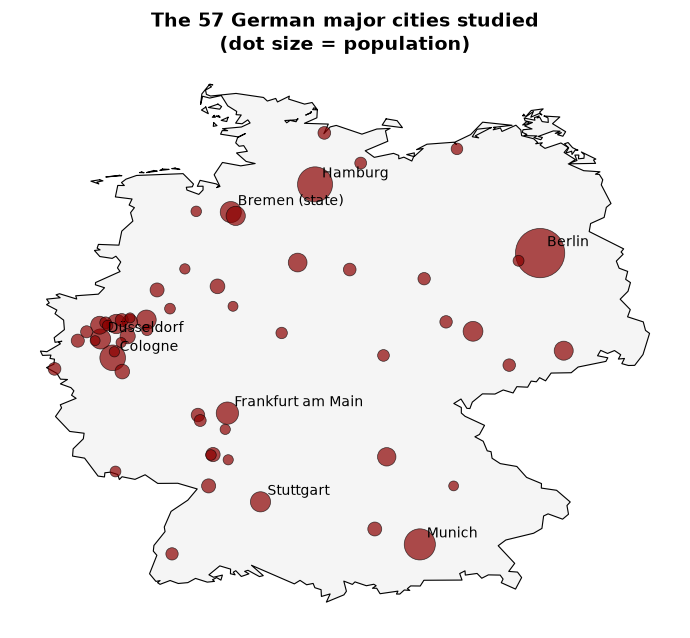

In [2]:
# Mostly AI-generated, used only for visualization
# Germany outline (public GeoJSON, low resolution -- plenty for an overview map)
geo_url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/1_deutschland/4_niedrig.geo.json"
germany_outline = requests.get(geo_url, timeout=30).json()

fig, ax = plt.subplots(figsize=(7, 9))

for polygon in germany_outline["features"][0]["geometry"]["coordinates"]:
    for ring in polygon:
        ring = np.array(ring)
        ax.plot(ring[:, 0], ring[:, 1], color="black", linewidth=0.8)
        ax.fill(ring[:, 0], ring[:, 1], color="whitesmoke", zorder=0)

ax.scatter(cities_df["lon"], cities_df["lat"], s=cities_df["population"] / 3000,
           alpha=0.7, color="darkred", edgecolor="black", linewidth=0.5, zorder=3)
for _, row in cities_df.head(8).iterrows():
    ax.annotate(row["city"], (row["lon"], row["lat"]), fontsize=10,
                xytext=(5, 5), textcoords="offset points", zorder=4)

ax.set_title("The 57 German major cities studied\n(dot size = population)",
              fontsize=14, fontweight="bold")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("data/processed/rq1_map_cities.svg")
plt.savefig("data/processed/rq1_map_cities.png", dpi=400)
plt.show()

### Step 2 - Connecting to the weather API

A persistent, never-expiring cache (`requests_cache`) plus a retry
strategy for HTTP 429 ("Too Many Requests") make the 57-city, 45-year
collection resumable and safe against the API's rate limit.

In [3]:
# Open-Meteo client: FlatBuffers client + persistent cache + custom retry logic (incl. 429)
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def make_client():
    # Cache never expires: past weather data doesn't change.
    cache_session = requests_cache.CachedSession(
        "openmeteo_cache", expire_after=-1, allowable_codes=[200],
    )
    # Retry with growing wait times on rate limits and server errors.
    retry = Retry(
        total=6, backoff_factor=3,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    cache_session.mount("https://", HTTPAdapter(max_retries=retry))
    cache_session.headers.update({"User-Agent": "student-project/1.0"})
    return openmeteo_requests.Client(session=cache_session)


CLIENT = make_client()

### Step 3 - Fetching temperatures and detecting heatwaves

- `fetch_tmax_batch` / `fetch_tmax_range`: load daily max temperatures,
  batched by city and by year.
- `compute_doy_thresholds`: per-calendar-day 98th percentile from the
  1961-1990 reference period.
- `find_dwd_heatwaves`: finds runs of >= 3 days above both thresholds.
- `analyze_city_heatwaves_from_data`: combines the two for one city.

In [4]:
# Functions: fetch weather data (openmeteo_requests) + detect heatwaves
import time

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"


def fetch_tmax_batch(client, coords, start_date, end_date, batch_size=15, pause=5):
    """Fetch daily maximum temperatures for several cities at once."""
    dfs = []
    n_batches = -(-len(coords) // batch_size)  # ceiling division

    for b in range(n_batches):
        i = b * batch_size
        chunk = coords[i:i + batch_size]

        params = {
            "latitude": [lat for lat, lon in chunk],
            "longitude": [lon for lat, lon in chunk],
            "start_date": start_date, "end_date": end_date,
            "daily": ["temperature_2m_max"],
            "timezone": "Europe/Berlin",
        }
        try:
            responses = client.weather_api(ARCHIVE_URL, params=params)  # always a list, one entry per city
        except Exception as e:
            raise RuntimeError(f"API error in batch {b + 1}/{n_batches}: {e}") from e

        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()  # index 0 -- the only variable requested
            # Open-Meteo returns start/end/interval instead of an explicit date list
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))

        print(f"  Batch {b + 1}/{n_batches} ok ({len(chunk)} cities)")
        time.sleep(pause)  # keep the request rate below the API's rate limit

    return dfs


def fetch_tmax_range(client, coords, start_date, end_date, batch_size=15, year_chunk=5, pause=5):
    """Fetch tmax over a long period, split into city and year batches."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])

    year_ranges = []
    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        year_ranges.append((f"{y}-01-01", f"{y2}-12-31"))
        y = y2 + 1

    all_parts = {i: [] for i in range(len(coords))}
    for chunk_start, chunk_end in year_ranges:
        print(f"Period {chunk_start[:4]}-{chunk_end[:4]}:")
        dfs = fetch_tmax_batch(client, coords, chunk_start, chunk_end, batch_size=batch_size, pause=pause)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        time.sleep(pause)  # extra buffer between year blocks

    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]


def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """Threshold per calendar day: 98th percentile within +/-15 days of the reference period."""
    doy = ref_df["doy"].to_numpy()
    tmax = ref_df["tmax"].to_numpy()
    thresholds = {}

    for d in range(1, 366):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)  # wrap around the turn of the year
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)

    return thresholds


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """A heatwave is >= 3 consecutive days above both the climate threshold AND 28 degrees C."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)  # leap-year day 366 folds into 365
    df["threshold"] = df["doy"].map(thresholds)
    df["is_hot"] = (df["tmax"] > df["threshold"]) & (df["tmax"] > fixed_threshold)

    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i
        elif not row["is_hot"] and start is not None:
            segment = df.loc[start:i - 1]
            if len(segment) >= min_days:
                heatwaves.append({
                    "start": segment["date"].iloc[0].date(),
                    "end": segment["date"].iloc[-1].date(),
                    "duration_days": len(segment),
                    "max_temp": round(segment["tmax"].max(), 1),
                    "avg_temp": round(segment["tmax"].mean(), 1),
                })
            start = None

    if start is not None:  # data ends mid-heatwave
        segment = df.loc[start:]
        if len(segment) >= min_days:
            heatwaves.append({
                "start": segment["date"].iloc[0].date(),
                "end": segment["date"].iloc[-1].date(),
                "duration_days": len(segment),
                "max_temp": round(segment["tmax"].max(), 1),
                "avg_temp": round(segment["tmax"].mean(), 1),
            })

    return heatwaves


def analyze_city_heatwaves_from_data(ref_df, analysis_df):
    """Combine threshold calculation and heatwave search for a single city."""
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    thresholds = compute_doy_thresholds(ref_df)
    return find_dwd_heatwaves(analysis_df, thresholds)

### Step 4 - Smoke test

A small 3-city, 1-month request confirms the pipeline works before the
full run. Commented out below to skip a live call on every execution
(originally returned `[31, 31, 31]`).

In [5]:
# Smoke test: confirm the client + fetch_tmax_batch work (3 cities, one month)
# coords = list(zip(cities_df["lat"], cities_df["lon"]))
# test = fetch_tmax_batch(CLIENT, coords[:3], "2025-01-01", "2025-01-31")
# [len(df) for df in test]  # -> [31, 31, 31]

### Step 5 - Running the full collection (used by the website)

The code below was run once (~10 minutes) to fetch both periods for all
57 cities, detect heatwaves per city, and save the results. This notebook
picks up from those saved files. `heatwaves.csv` is the file the website
uses (see the note at the top of this notebook).

coords = list(zip(cities_df["lat"], cities_df["lon"]))

In [ ]:
### Step 5 - Running the full collection (used by the website)

coords = list(zip(cities_df["lat"], cities_df["lon"]))

ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", batch_size=15, year_chunk=10, pause=1)
analysis_dfs = fetch_tmax_range(CLIENT, coords, "1980-01-01", "2025-12-31", batch_size=15, year_chunk=5, pause=1)

results = []
failed_cities = []
for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    try:
        heatwaves = analyze_city_heatwaves_from_data(ref_dfs[idx], analysis_dfs[idx])
        for hw in heatwaves:
            results.append({"city": row["city"], "population": row["population"], **hw})
    except Exception as e:
        print(f"  Skipped due to error ({row['city']}): {e}")
        failed_cities.append(row["city"])

results_df = pd.DataFrame(results)
results_df["year"] = pd.to_datetime(results_df["start"]).dt.year

import os
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

raw_rows = [analysis_dfs[idx].assign(city=row["city"])
            for idx, row in cities_df.iterrows() if idx not in exclude_idx]
pd.concat(raw_rows, ignore_index=True).to_parquet("data/raw/tmax_1980_2025.parquet", index=False)

ref_rows = [ref_dfs[idx].assign(city=row["city"])
            for idx, row in cities_df.iterrows() if idx not in exclude_idx]
pd.concat(ref_rows, ignore_index=True).to_parquet("data/raw/tmax_1961_1990.parquet", index=False)

results_df.to_csv("data/processed/heatwaves.csv", index=False)  # copied to Website/data/RQ1_heatwaves_events.csv

In [6]:
# heatwaves.csv here is the same file the website reads (as RQ1_heatwaves_events.csv)
results_df = pd.read_csv("data/processed/heatwaves.csv", parse_dates=["start", "end"])
tmax_df = pd.read_parquet("data/raw/tmax_1980_2025.parquet")
ref_df = pd.read_parquet("data/raw/tmax_1961_1990.parquet")

print(f"{len(results_df)} heatwaves loaded, covering {results_df['city'].nunique()} cities")

1570 heatwaves loaded, covering 56 cities


## 2. Illustrating the method

Berlin, 2003 - the famous European heatwave - as a worked example before
scaling up to all 57 cities.

Daily maximum temperature for Berlin, 2003. Dashed line = 28 degrees
C threshold.

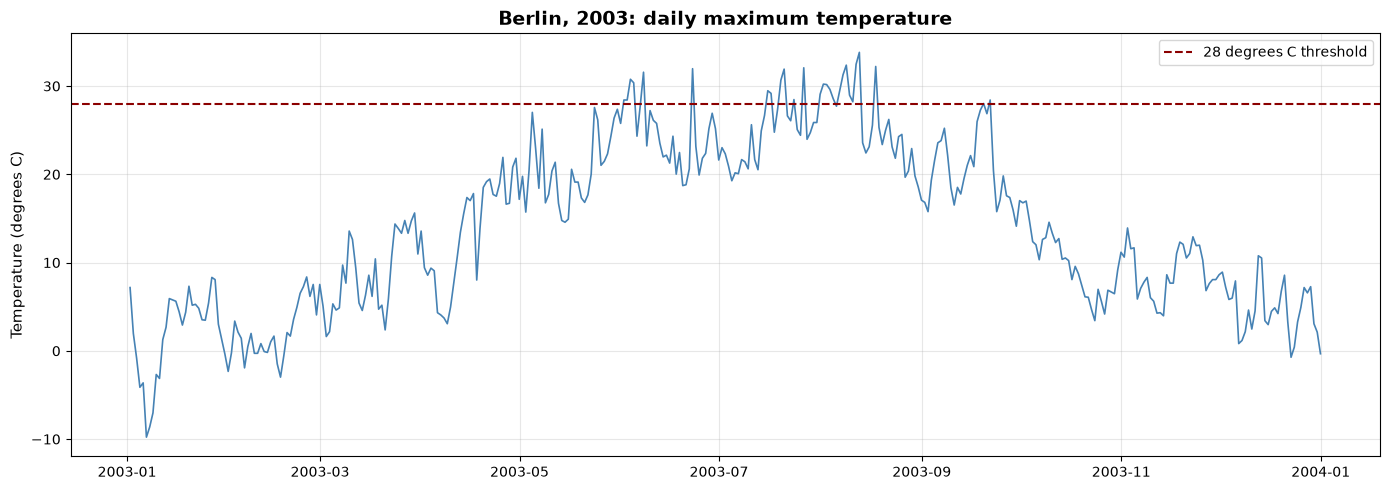

In [7]:
berlin_2003 = tmax_df[(tmax_df["city"] == "Berlin") & (tmax_df["date"].dt.year == 2003)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(berlin_2003["date"], berlin_2003["tmax"], color="steelblue", linewidth=1.2)
ax.axhline(28, color="darkred", linestyle="--", label="28 degrees C threshold")
ax.set_title("Berlin, 2003: daily maximum temperature", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (degrees C)", fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rq1_berlin2003_daily.svg")
plt.savefig("data/processed/rq1_berlin2003_daily.png", dpi=400)
plt.show()

What counts as "unusually hot" for Berlin: the 1961-1990 threshold
(orange) vs. the actual 2003 temperatures (blue). A day only counts once
it crosses the orange line.

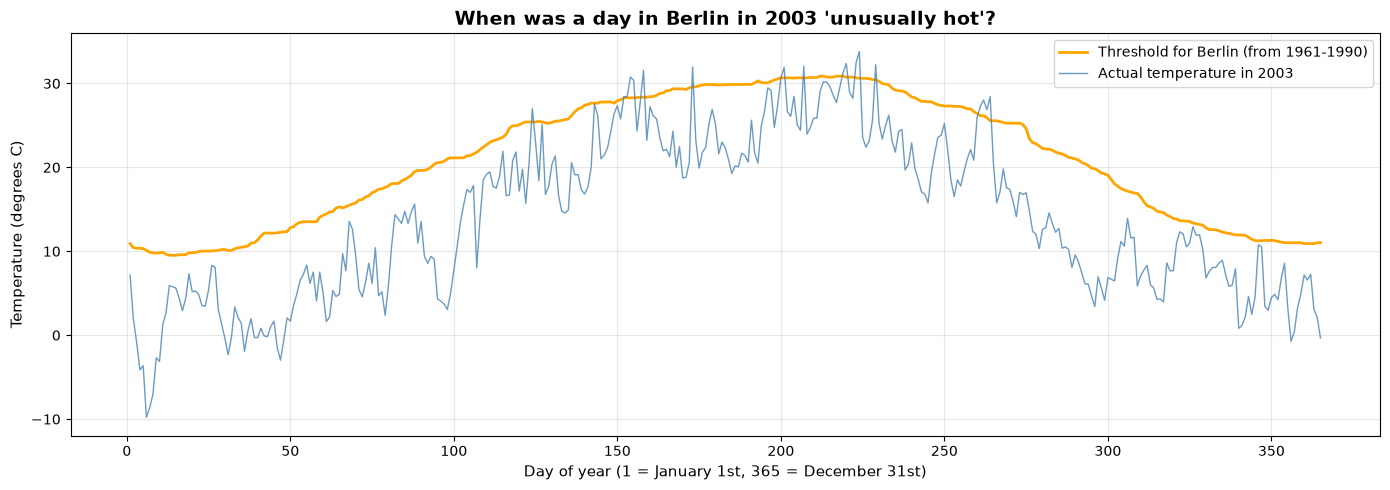

In [8]:
ref_berlin = ref_df[ref_df["city"] == "Berlin"].copy()
ref_berlin["doy"] = ref_berlin["date"].dt.dayofyear.clip(upper=365)
thresholds_berlin = compute_doy_thresholds(ref_berlin)
threshold_curve = pd.Series(thresholds_berlin).sort_index()

berlin_2003_doy = berlin_2003.copy()
berlin_2003_doy["doy"] = berlin_2003_doy["date"].dt.dayofyear

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(threshold_curve.index, threshold_curve.values, color="orange", linewidth=2,
        label="Threshold for Berlin (from 1961-1990)")
ax.plot(berlin_2003_doy["doy"], berlin_2003_doy["tmax"], color="steelblue", linewidth=1, alpha=0.8,
        label="Actual temperature in 2003")
ax.set_title("When was a day in Berlin in 2003 'unusually hot'?", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of year (1 = January 1st, 365 = December 31st)", fontsize=11)
ax.set_ylabel("Temperature (degrees C)", fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rq1_berlin2003_threshold.svg")
plt.savefig("data/processed/rq1_berlin2003_threshold.png", dpi=400)
plt.show()

A detected heatwave, zoomed in.

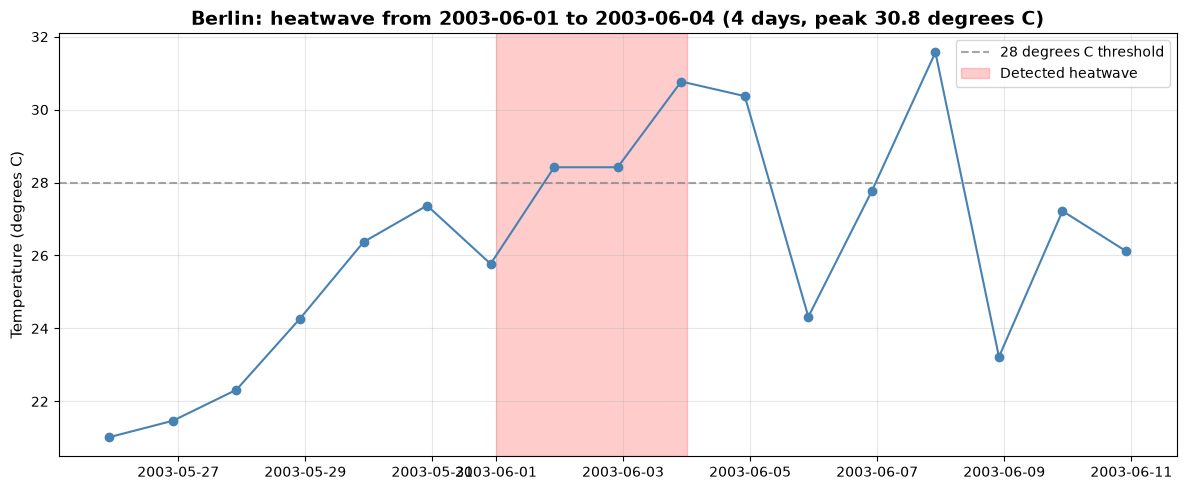

In [9]:
berlin_2003_events = results_df[(results_df["city"] == "Berlin") & (results_df["start"].dt.year == 2003)]
longest = berlin_2003_events.sort_values("duration_days", ascending=False).iloc[0]

window_start = longest["start"] - pd.Timedelta(days=7)
window_end = longest["end"] + pd.Timedelta(days=7)
berlin_all = tmax_df[tmax_df["city"] == "Berlin"]
window = berlin_all[(berlin_all["date"] >= window_start) & (berlin_all["date"] <= window_end)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(window["date"], window["tmax"], marker="o", color="steelblue")
ax.axhline(28, color="gray", linestyle="--", alpha=0.7, label="28 degrees C threshold")
ax.axvspan(longest["start"], longest["end"], color="red", alpha=0.2, label="Detected heatwave")
ax.set_title(f"Berlin: heatwave from {longest['start'].date()} to {longest['end'].date()} "
             f"({longest['duration_days']} days, peak {longest['max_temp']} degrees C)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (degrees C)", fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rq1_berlin_heatwave_zoom.svg")
plt.savefig("data/processed/rq1_berlin_heatwave_zoom.png", dpi=400)
plt.show()

`results_df` already holds this same process for all 57 cities and
46 years.

## 3. The big picture: 45 years, 57 cities

Four metrics per year, across all cities.

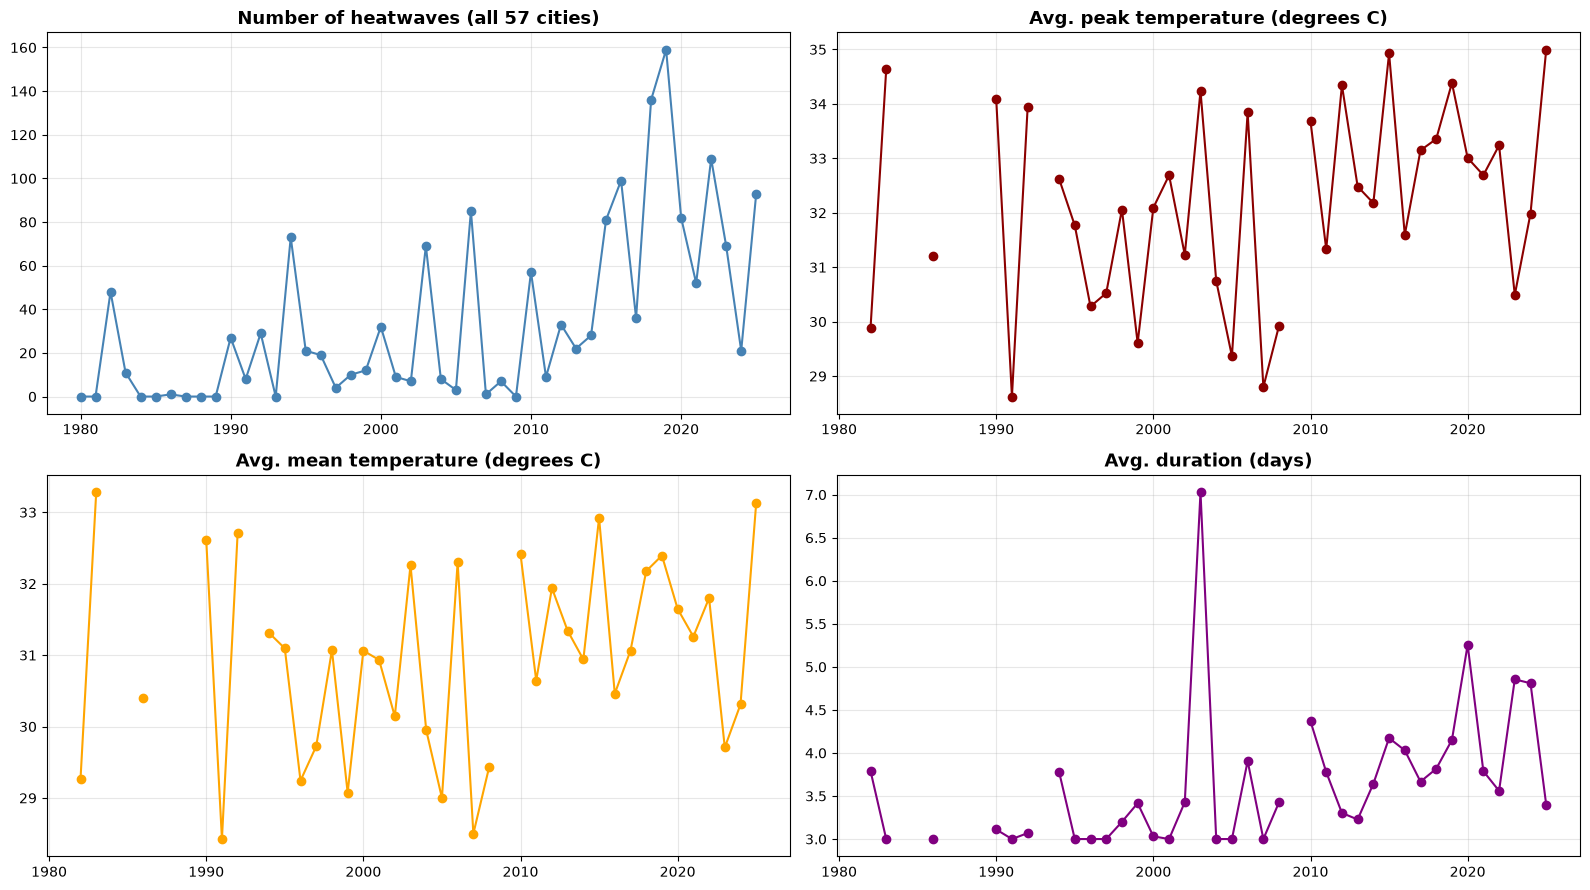

In [10]:
all_years = pd.DataFrame({"year": range(1980, 2026)})
yearly = all_years.merge(
    results_df.groupby("year").agg(
        n_heatwaves=("city", "count"), avg_max_temp=("max_temp", "mean"),
        avg_avg_temp=("avg_temp", "mean"), avg_duration=("duration_days", "mean"),
    ).reset_index(), on="year", how="left")
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plots = [("n_heatwaves", "Number of heatwaves (all 57 cities)", axes[0, 0], "steelblue"),
         ("avg_max_temp", "Avg. peak temperature (degrees C)", axes[0, 1], "darkred"),
         ("avg_avg_temp", "Avg. mean temperature (degrees C)", axes[1, 0], "orange"),
         ("avg_duration", "Avg. duration (days)", axes[1, 1], "purple")]
for col, label, ax, color in plots:
    ax.plot(yearly["year"], yearly[col], marker="o", color=color)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rq1_yearly_overview.svg")
plt.savefig("data/processed/rq1_yearly_overview.png", dpi=400)
plt.show()

### Is this a real trend?

Linear regression per metric. Green = statistically significant
(p < 0.05).

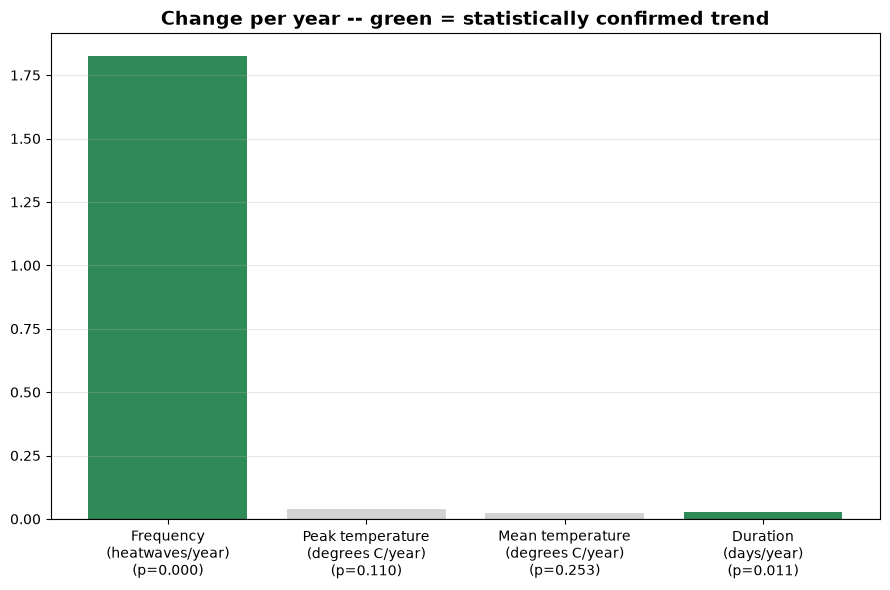

In [11]:
from scipy import stats

metrics = [("n_heatwaves", "Frequency\n(heatwaves/year)"), ("avg_max_temp", "Peak temperature\n(degrees C/year)"),
           ("avg_avg_temp", "Mean temperature\n(degrees C/year)"), ("avg_duration", "Duration\n(days/year)")]

slopes, colors, labels = [], [], []
for col, label in metrics:
    valid = yearly.dropna(subset=[col])
    slope, _, _, p, _ = stats.linregress(valid["year"], valid[col])
    slopes.append(slope)
    colors.append("seagreen" if p < 0.05 else "lightgray")
    labels.append(f"{label}\n(p={p:.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(labels, slopes, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Change per year -- green = statistically confirmed trend", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/rq1_significance.svg")
plt.savefig("data/processed/rq1_significance.png", dpi=400)
plt.show()

## 4. Exploring each metric

Same four metrics, smoothed with a 5-year rolling average (as on the
project website).

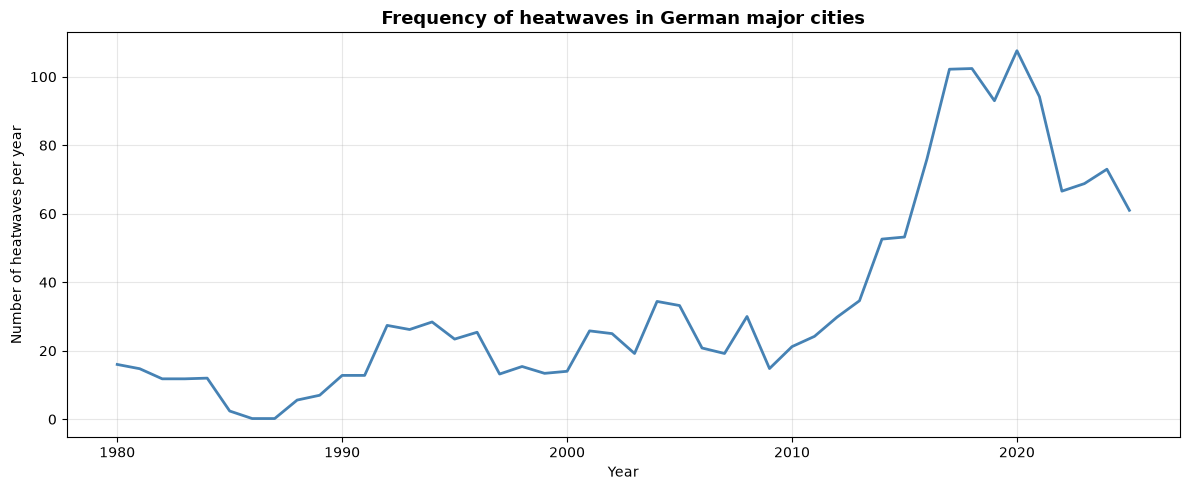

n_heatwaves: trend is statistically significant (p=0.0000), slope=+1.8245/year


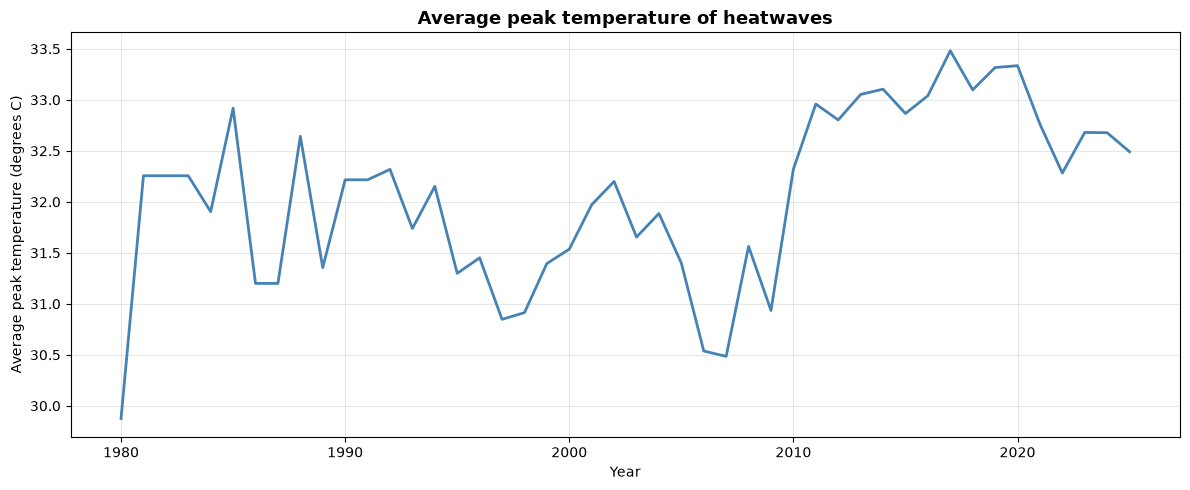

avg_max_temp: trend is not statistically significant at the 5% level (p=0.1100), slope=+0.0394/year


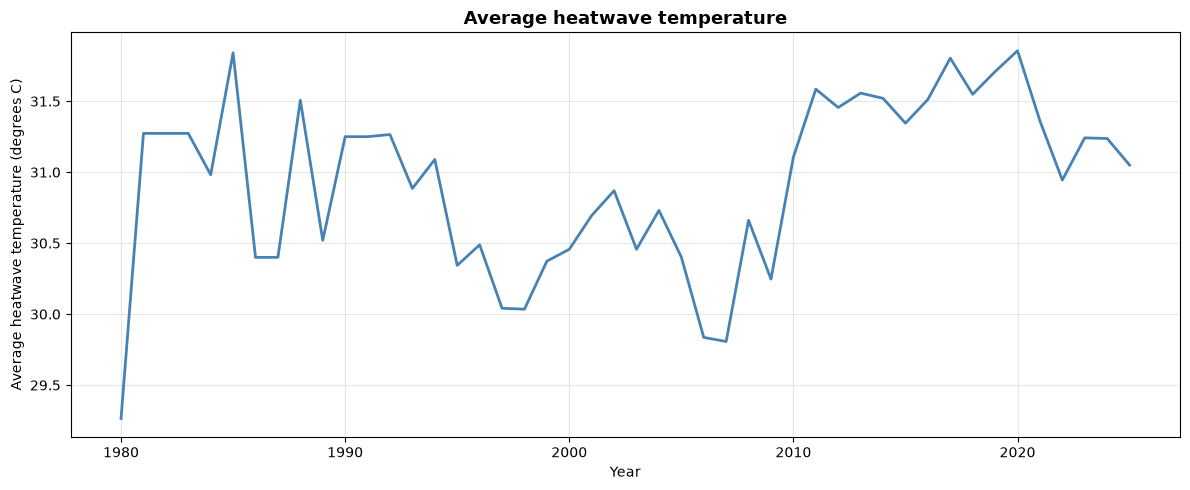

avg_avg_temp: trend is not statistically significant at the 5% level (p=0.2532), slope=+0.0214/year


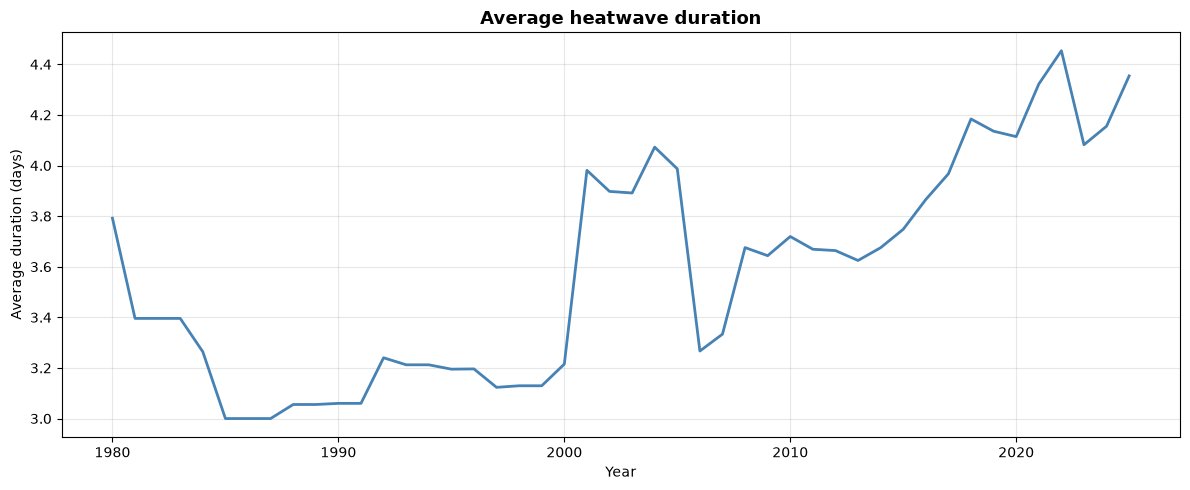

avg_duration: trend is statistically significant (p=0.0107), slope=+0.0280/year


In [12]:
metrics_info = [
    ("n_heatwaves", "Frequency of heatwaves in German major cities", "Number of heatwaves per year"),
    ("avg_max_temp", "Average peak temperature of heatwaves", "Average peak temperature (degrees C)"),
    ("avg_avg_temp", "Average heatwave temperature", "Average heatwave temperature (degrees C)"),
    ("avg_duration", "Average heatwave duration", "Average duration (days)"),
]

for col, title, ylabel in metrics_info:
    valid = yearly.dropna(subset=[col])
    slope, _, _, p, _ = stats.linregress(valid["year"], valid[col])
    smoothed = yearly[col].rolling(window=5, center=True, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yearly["year"], smoothed, color="steelblue", linewidth=2)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    sig = "statistically significant" if p < 0.05 else "not statistically significant at the 5% level"
    print(f"{col}: trend is {sig} (p={p:.4f}), slope={slope:+.4f}/year")

### City comparison

Top 15 cities per metric, 1980-2025.

C:\Users\konta\AppData\Local\Temp\ipykernel_29404\355032263.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top.index, rotation=35, ha="right")


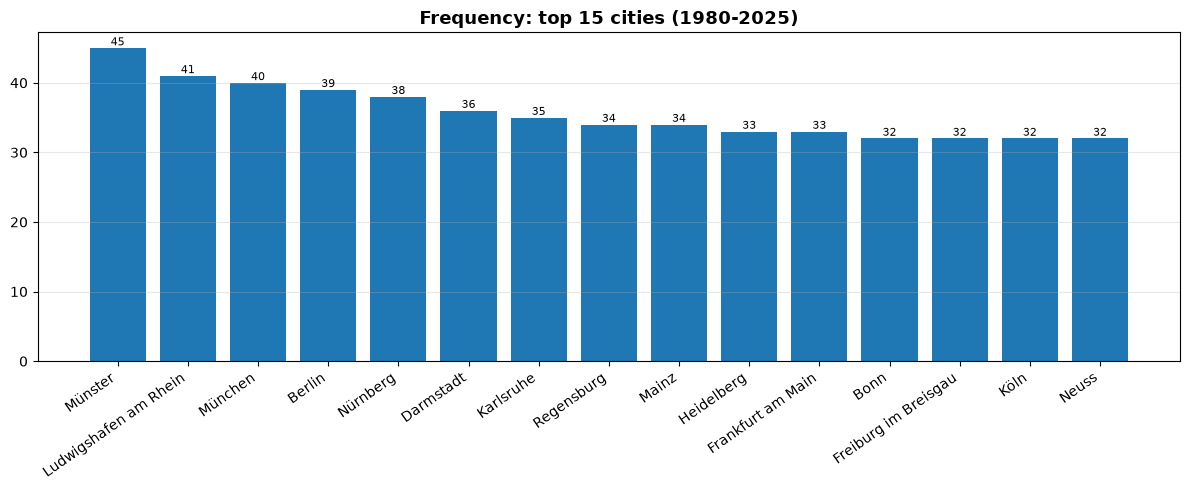

city
Münster                  45
Ludwigshafen am Rhein    41
München                  40
Berlin                   39
Nürnberg                 38
Darmstadt                36
Karlsruhe                35
Regensburg               34
Mainz                    34
Heidelberg               33
Frankfurt am Main        33
Bonn                     32
Freiburg im Breisgau     32
Köln                     32
Neuss                    32 



C:\Users\konta\AppData\Local\Temp\ipykernel_29404\355032263.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top.index, rotation=35, ha="right")


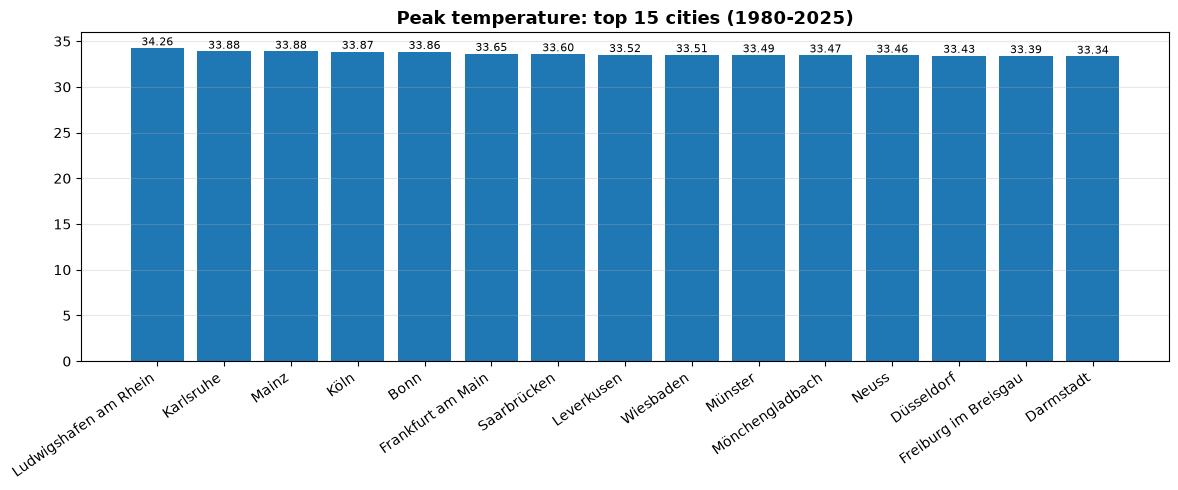

city
Ludwigshafen am Rhein    34.26
Karlsruhe                33.88
Mainz                    33.88
Köln                     33.87
Bonn                     33.86
Frankfurt am Main        33.65
Saarbrücken              33.60
Leverkusen               33.52
Wiesbaden                33.51
Münster                  33.49
Mönchengladbach          33.47
Neuss                    33.46
Düsseldorf               33.43
Freiburg im Breisgau     33.39
Darmstadt                33.34 



C:\Users\konta\AppData\Local\Temp\ipykernel_29404\355032263.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top.index, rotation=35, ha="right")


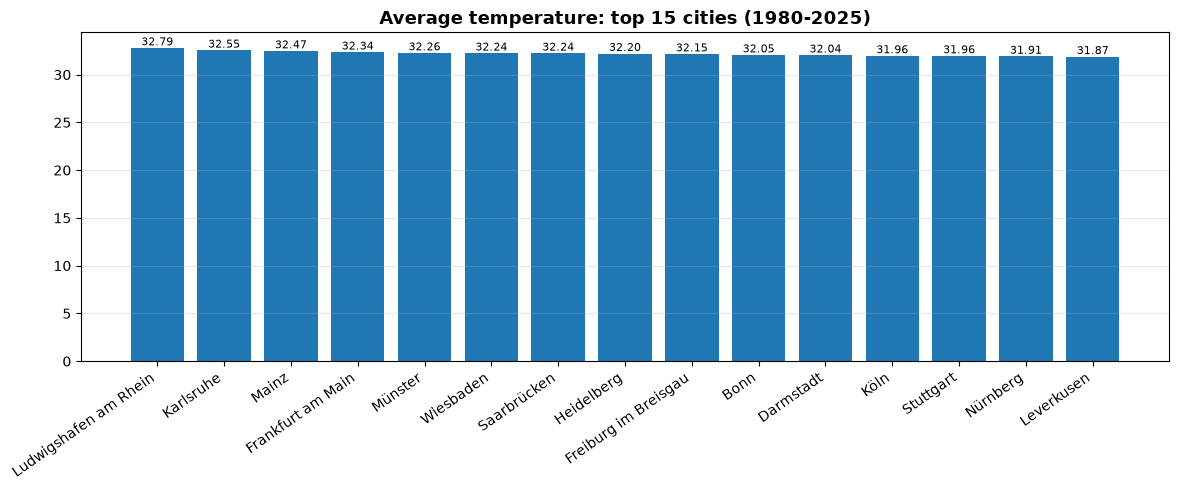

city
Ludwigshafen am Rhein    32.79
Karlsruhe                32.55
Mainz                    32.47
Frankfurt am Main        32.34
Münster                  32.26
Wiesbaden                32.24
Saarbrücken              32.24
Heidelberg               32.20
Freiburg im Breisgau     32.15
Bonn                     32.05
Darmstadt                32.04
Köln                     31.96
Stuttgart                31.96
Nürnberg                 31.91
Leverkusen               31.87 



C:\Users\konta\AppData\Local\Temp\ipykernel_29404\355032263.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top.index, rotation=35, ha="right")


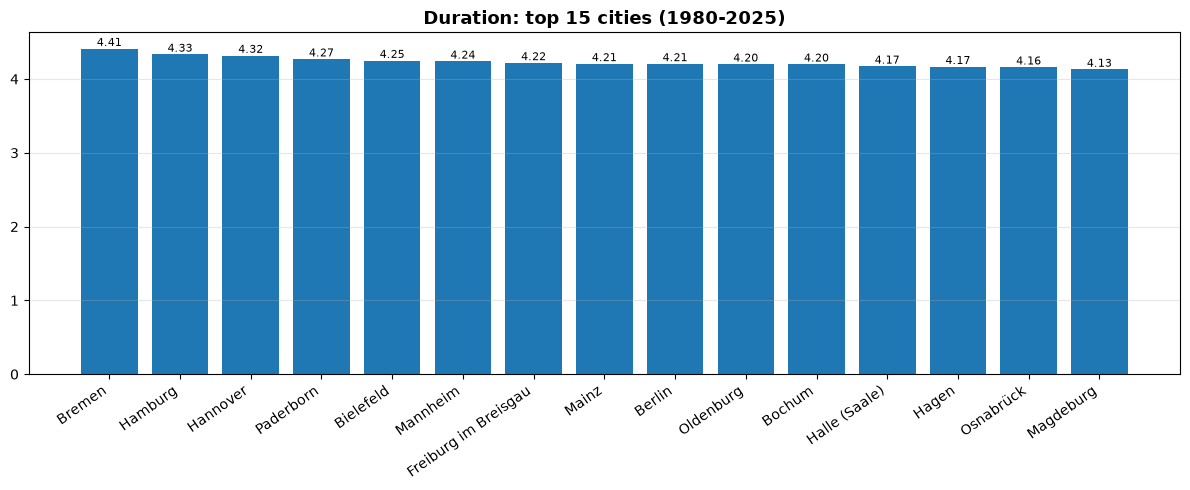

city
Bremen                  4.41
Hamburg                 4.33
Hannover                4.32
Paderborn               4.27
Bielefeld               4.25
Mannheim                4.24
Freiburg im Breisgau    4.22
Mainz                   4.21
Berlin                  4.21
Oldenburg               4.20
Bochum                  4.20
Halle (Saale)           4.17
Hagen                   4.17
Osnabrück               4.16
Magdeburg               4.13 



In [13]:
city_series = {
    "Frequency": results_df.groupby("city").size(),
    "Peak temperature": results_df.groupby("city")["max_temp"].mean(),
    "Average temperature": results_df.groupby("city")["avg_temp"].mean(),
    "Duration": results_df.groupby("city")["duration_days"].mean(),
}

for label, series in city_series.items():
    top = series.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(top.index, top.values, color="tab:blue")
    ax.set_title(f"{label}: top 15 cities (1980-2025)", fontsize=13, fontweight="bold")
    ax.set_xticklabels(top.index, rotation=35, ha="right")
    fmt = "{:.0f}" if label == "Frequency" else "{:.2f}"
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), fmt.format(val),
                 ha="center", va="bottom", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(top.round(2).to_string(), "\n")

### Trend statistics

Full period (1980-2025) vs. 1991-2025, to check the trend is not an
artifact of the overlap between the analysis and reference periods.

In [14]:
def trend_table(data):
    rows = []
    for col, label in [("n_heatwaves", "Frequency"), ("avg_max_temp", "Peak temperature"),
                        ("avg_avg_temp", "Average temperature"), ("avg_duration", "Duration")]:
        valid = data.dropna(subset=[col])
        slope, _, _, p, _ = stats.linregress(valid["year"], valid[col])
        rows.append({
            "Metric": label,
            "Trend per year": f"{slope:+.4f}",
            "p-value": f"{p:.4f}" if p >= 0.0001 else "<0.0001",
            "Significant": "Yes" if p < 0.05 else "No",
        })
    return pd.DataFrame(rows)


main_table = trend_table(yearly)
sensitivity_table = trend_table(yearly[yearly["year"] >= 1991])

print("Main results (1980-2025)")
print(main_table.to_string(index=False))
print("\nSensitivity check (1991-2025, no overlap with the reference period)")
print(sensitivity_table.to_string(index=False))

Main results (1980-2025)
             Metric Trend per year p-value Significant
          Frequency        +1.8245 <0.0001         Yes
   Peak temperature        +0.0394  0.1100          No
Average temperature        +0.0214  0.2532          No
           Duration        +0.0280  0.0107         Yes

Sensitivity check (1991-2025, no overlap with the reference period)
             Metric Trend per year p-value Significant
          Frequency        +2.2936  0.0005         Yes
   Peak temperature        +0.0674  0.0245         Yes
Average temperature        +0.0433  0.0527          No
           Duration        +0.0332  0.0206         Yes


### Bonus: decade view

Same frequency/duration trends, binned by decade (used on the project
poster).

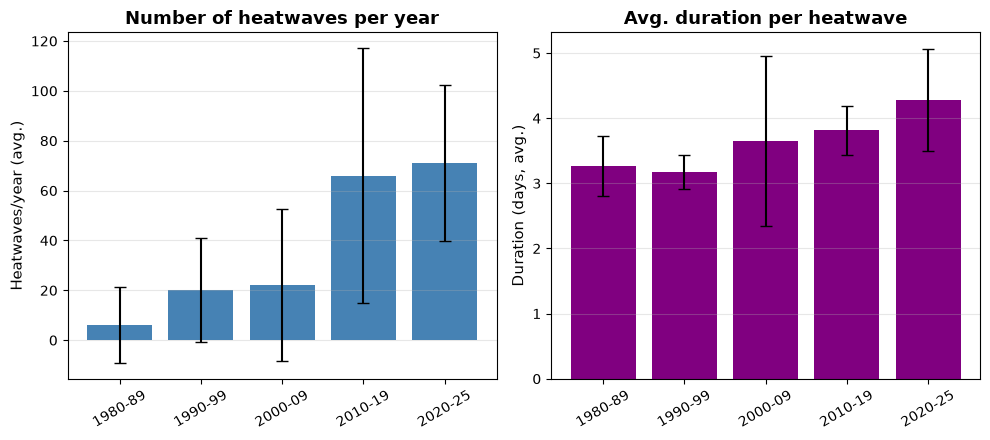

In [15]:
def decade_bin(year):
    if year < 1990:
        return "1980-89"
    elif year < 2000:
        return "1990-99"
    elif year < 2010:
        return "2000-09"
    elif year < 2020:
        return "2010-19"
    else:
        return "2020-25"


yearly["decade"] = yearly["year"].apply(decade_bin)
decade_order = ["1980-89", "1990-99", "2000-09", "2010-19", "2020-25"]

decade_stats = yearly.groupby("decade").agg(
    freq_mean=("n_heatwaves", "mean"), freq_std=("n_heatwaves", "std"),
    dur_mean=("avg_duration", "mean"), dur_std=("avg_duration", "std"),
).reindex(decade_order)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(decade_order, decade_stats["freq_mean"], yerr=decade_stats["freq_std"],
            color="steelblue", capsize=4)
axes[0].set_title("Number of heatwaves per year", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Heatwaves/year (avg.)", fontsize=11)
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(decade_order, decade_stats["dur_mean"], yerr=decade_stats["dur_std"],
            color="purple", capsize=4)
axes[1].set_title("Avg. duration per heatwave", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Duration (days, avg.)", fontsize=11)
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/poster_decade_bars.png", dpi=400)
plt.savefig("data/processed/poster_decade_bars.svg")  # vector graphic -- stays sharp at any size, e.g. for slides
plt.show()